In [1]:
import scanpy as sc
import pandas as pd
import json
import gzip

In [2]:
import numpy as np

In [3]:
import squidpy as sq

/nfs/users/nfs_m/ms83/.local/lib/python3.10/site-packages/dask/dataframe/__init__.py:31: FutureWarning: The legacy Dask DataFrame implementation is deprecated and will be removed in a future version. Set the configuration option `dataframe.query-planning` to `True` or None to enable the new Dask Dataframe implementation and silence this warning.
  warnings.warn(
/nfs/users/nfs_m/ms83/.local/lib/python3.10/site-packages/numba/core/decorators.py:246: RuntimeWarning: nopython is set for njit and is ignored
  warnings.warn('nopython is set for njit and is ignored', RuntimeWarning)
/nfs/users/nfs_m/ms83/.local/lib/python3.10/site-packages/anndata/utils.py:429: FutureWarning: Importing read_text from `anndata` is deprecated. Import anndata.io.read_text instead.
  warnings.warn(msg, FutureWarning)


In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
path = '/nfs/team361/ms83/data/CRC/visiumHD_mintflow/raw_data/'

In [6]:
adata = sc.read_h5ad(path + "adata_sc_P1_rawformintflow.h5ad")

In [7]:
adata

AnnData object with n_obs × n_vars = 235530 × 18085
    obs: 'tissue', 'X', 'Y', 'DeconvolutionClass', 'DeconvolutionLabel1', 'DeconvolutionLabel2', 'Periphery', 'UnsupervisedL1', 'UnsupervisedL2', 'MacrophageSubtype', 'GobletSubcluster', 'patient', 'patient_id'
    var: 'gene_ids', 'feature_types', 'genome'
    uns: 'DeconvolutionLabel1_colors', 'DeconvolutionLabel2_colors', 'spatial'
    obsm: 'spatial'

/nfs/users/nfs_m/ms83/.local/lib/python3.10/site-packages/squidpy/pl/_spatial_utils.py:976: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  _cax = scatter(


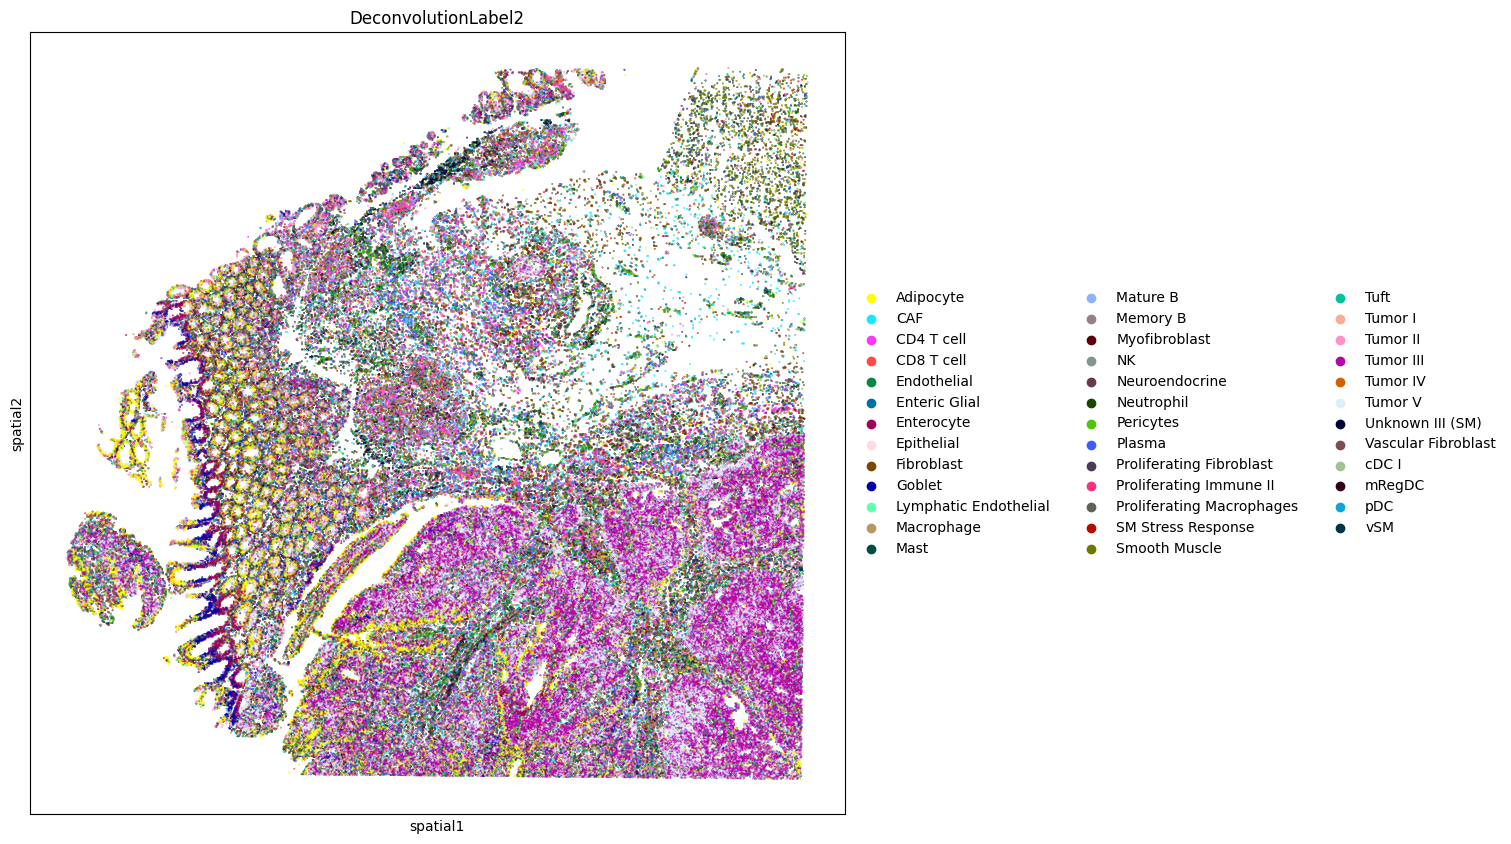

In [7]:
sq.pl.spatial_scatter(
    adata,
    library_id="spatial",
    shape=None,
    color=[
        "DeconvolutionLabel2",
    ],
    wspace=0.4,
    size=0.2,
    figsize=(15, 15)
)

In [ ]:
sq.pl.spatial_scatter(
    adata,
    library_id="spatial",
    shape=None,
    color=[
        "CXCL13", "LTA", "CXCR5",
    ],
    wspace=0.4,
    size=0.2,
    figsize=(15, 15)
)

In [10]:
import numpy as np
import scipy.sparse as sp

if sp.issparse(adata.X):
    adata.X = adata.X.astype(np.float32)
else:
    adata.X = adata.X.astype(np.float32)


In [11]:
print(type(adata.X))
print(adata.X.dtype)

<class 'scipy.sparse._csr.csr_matrix'>
float32


In [12]:
adata.write_h5ad(path + "adata_sc_P1_rawformintflow_float32.h5ad")

In [16]:
adata = sc.read_h5ad(path + "adata_sc_P1_rawformintflow.h5ad")

In [14]:
adata

AnnData object with n_obs × n_vars = 235530 × 18085
    obs: 'tissue', 'X', 'Y', 'DeconvolutionClass', 'DeconvolutionLabel1', 'DeconvolutionLabel2', 'Periphery', 'UnsupervisedL1', 'UnsupervisedL2', 'MacrophageSubtype', 'GobletSubcluster', 'patient', 'patient_id'
    var: 'gene_ids', 'feature_types', 'genome'
    uns: 'DeconvolutionLabel1_colors', 'DeconvolutionLabel2_colors', 'spatial'
    obsm: 'spatial'

In [17]:
adata.layers["counts"] = adata.X.copy()
sc.pp.normalize_total(adata, inplace=True)
sc.pp.log1p(adata)
sc.pp.pca(adata)

In [18]:
sc.pp.neighbors(adata)
sc.tl.umap(adata)

In [19]:
sq.gr.spatial_neighbors(adata, coord_type="generic", delaunay=True)

In [21]:
sq.gr.centrality_scores(adata, cluster_key="DeconvolutionLabel2")

/nfs/users/nfs_m/ms83/.local/lib/python3.10/site-packages/IPython/core/events.py:82: UserWarning: constrained_layout not applied because axes sizes collapsed to zero.  Try making figure larger or Axes decorations smaller.
  func(*args, **kwargs)
/nfs/users/nfs_m/ms83/.local/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: constrained_layout not applied because axes sizes collapsed to zero.  Try making figure larger or Axes decorations smaller.
  fig.canvas.print_figure(bytes_io, **kw)


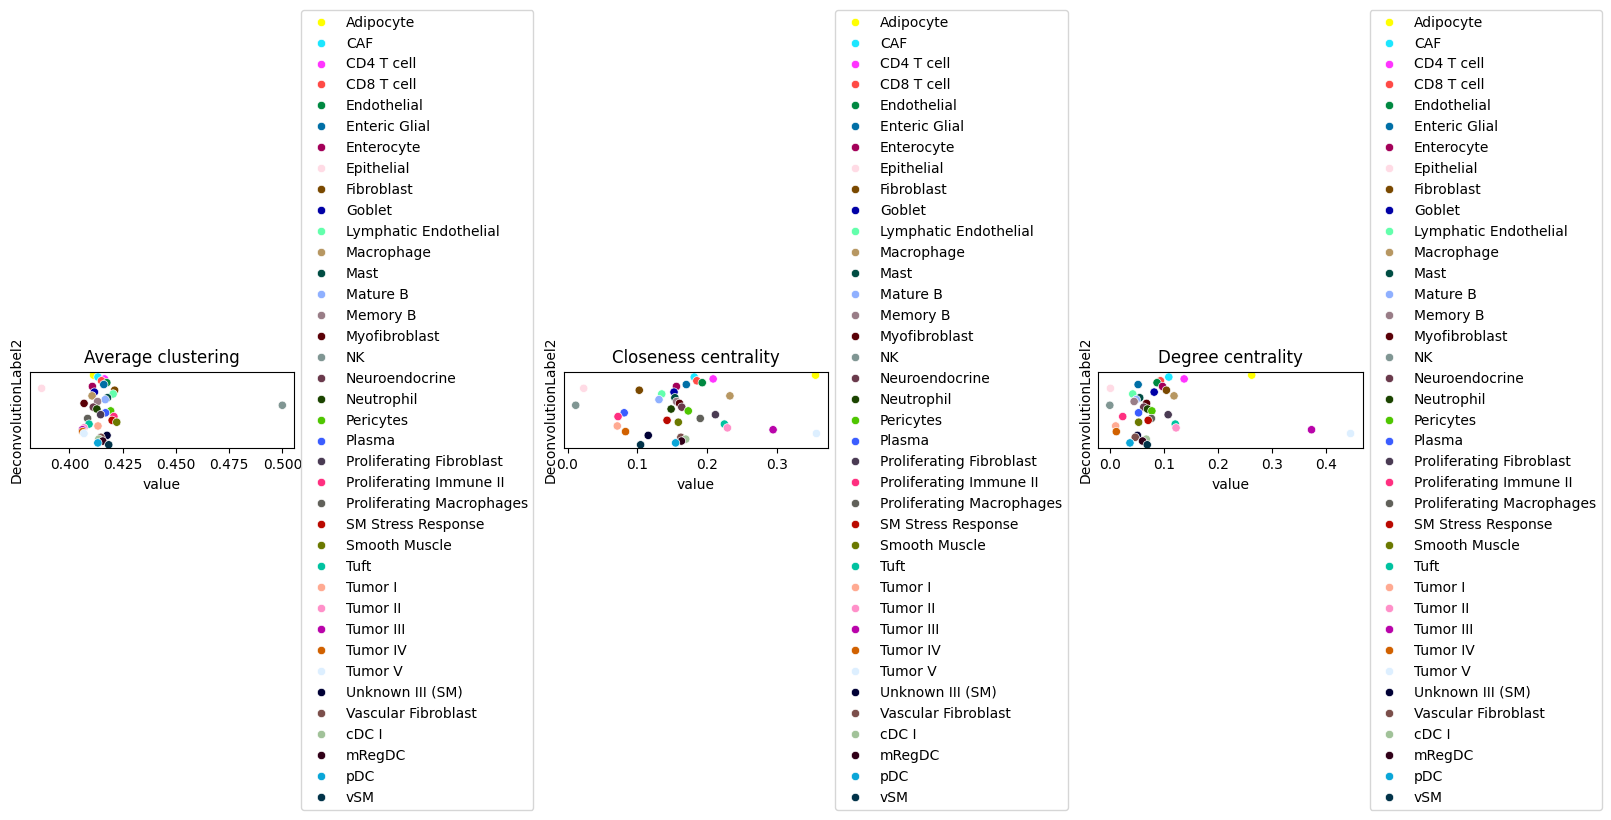

In [22]:
sq.pl.centrality_scores(adata, cluster_key="DeconvolutionLabel2", figsize=(16, 5))

In [24]:
adata_subsample = sc.pp.subsample(adata, fraction=0.5, copy=True)

In [25]:
sq.gr.co_occurrence(
    adata_subsample,
    cluster_key="DeconvolutionLabel2",
)
sq.pl.co_occurrence(
    adata_subsample,
    cluster_key="DeconvolutionLabel2",
    #clusters="12",
    figsize=(10, 10),
)
sq.pl.spatial_scatter(
    adata_subsample,
    color="DeconvolutionLabel2",
    shape=None,
    size=2,
)

  0%|          | 0/1711 [00:00<?, ?/s]

ValueError: No valid values were found. Valid values are `['Adipocyte', 'CAF', 'CD4 T cell', 'CD8 T cell', 'Endothelial', 'Enteric Glial', 'Enterocyte', 'Epithelial', 'Fibroblast', 'Goblet', 'Lymphatic Endothelial', 'Macrophage', 'Mast', 'Mature B', 'Memory B', 'Myofibroblast', 'NK', 'Neuroendocrine', 'Neutrophil', 'Pericytes', 'Plasma', 'Proliferating Fibroblast', 'Proliferating Immune II', 'Proliferating Macrophages', 'SM Stress Response', 'Smooth Muscle', 'Tuft', 'Tumor I', 'Tumor II', 'Tumor III', 'Tumor IV', 'Tumor V', 'Unknown III (SM)', 'Vascular Fibroblast', 'cDC I', 'mRegDC', 'pDC', 'vSM']`.

/nfs/users/nfs_m/ms83/.local/lib/python3.10/site-packages/squidpy/pl/_spatial_utils.py:976: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  _cax = scatter(
/nfs/users/nfs_m/ms83/.local/lib/python3.10/site-packages/IPython/core/events.py:82: UserWarning: constrained_layout not applied because axes sizes collapsed to zero.  Try making figure larger or Axes decorations smaller.
  func(*args, **kwargs)
/nfs/users/nfs_m/ms83/.local/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: constrained_layout not applied because axes sizes collapsed to zero.  Try making figure larger or Axes decorations smaller.
  fig.canvas.print_figure(bytes_io, **kw)


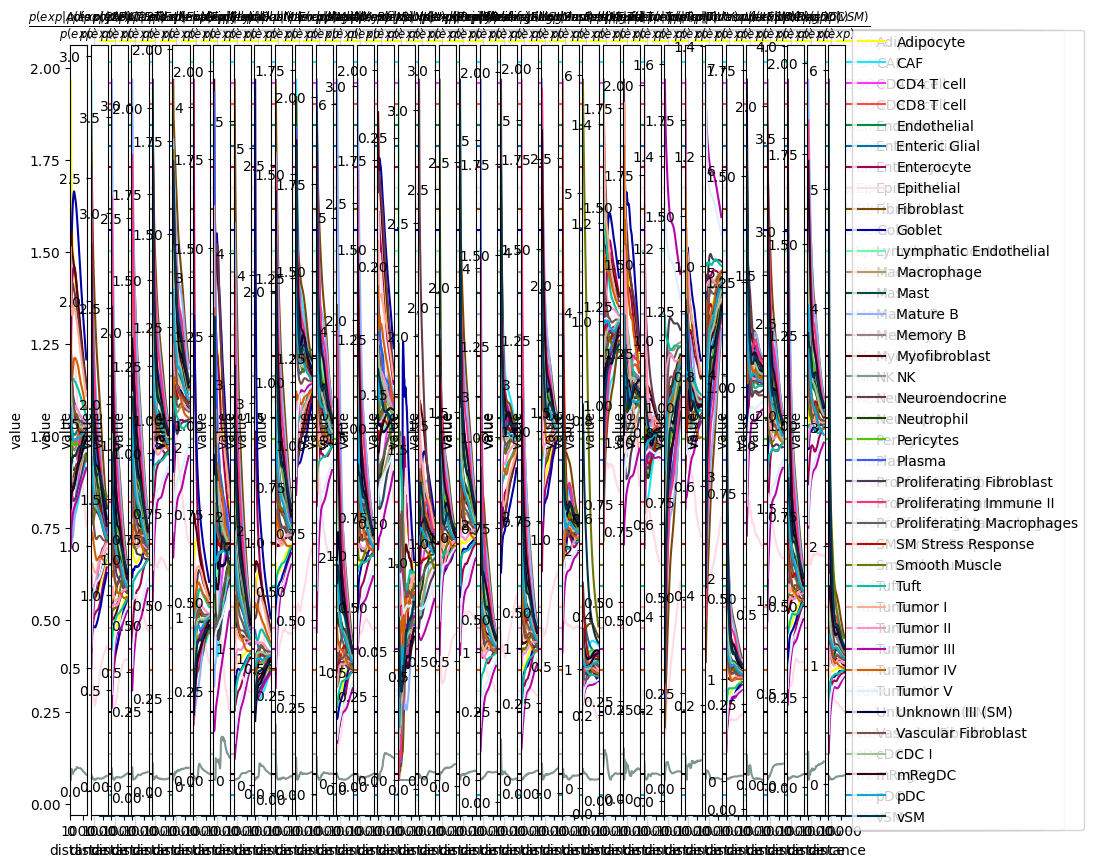

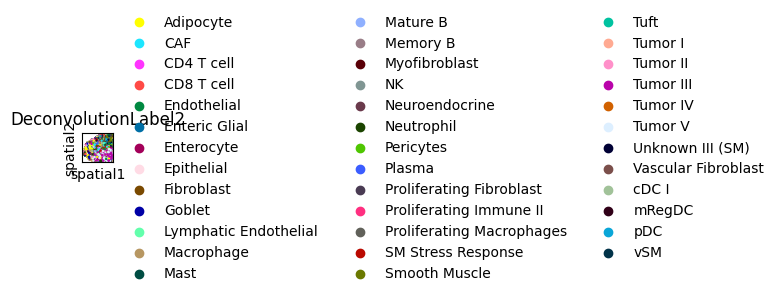

In [26]:
sq.pl.co_occurrence(
    adata_subsample,
    cluster_key="DeconvolutionLabel2",
    #clusters="12",
    figsize=(10, 10),
)
sq.pl.spatial_scatter(
    adata_subsample,
    color="DeconvolutionLabel2",
    shape=None,
    size=2,
)

In [27]:
sq.gr.nhood_enrichment(adata, cluster_key="DeconvolutionLabel2")

  0%|          | 0/1000 [00:00<?, ?/s]

/nfs/users/nfs_m/ms83/.local/lib/python3.10/site-packages/squidpy/gr/_nhood.py:202: RuntimeWarning: invalid value encountered in divide
  zscore = (count - perms.mean(axis=0)) / perms.std(axis=0)


/nfs/users/nfs_m/ms83/.local/lib/python3.10/site-packages/squidpy/pl/_spatial_utils.py:976: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  _cax = scatter(


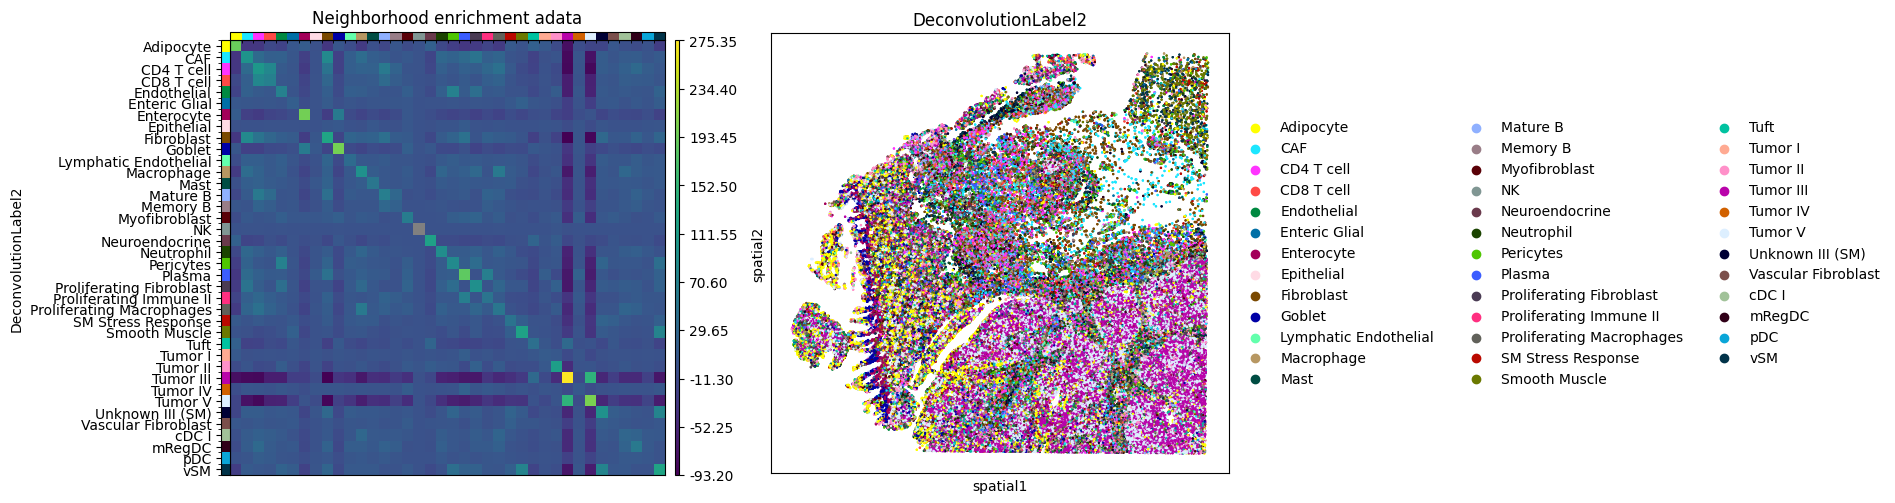

In [30]:
fig, ax = plt.subplots(1, 2, figsize=(13, 7))
sq.pl.nhood_enrichment(
    adata,
    cluster_key="DeconvolutionLabel2",
    figsize=(8, 8),
    title="Neighborhood enrichment adata",
    ax=ax[0],
)
sq.pl.spatial_scatter(adata_subsample, color="DeconvolutionLabel2", shape=None, size=2, ax=ax[1])

In [31]:
sq.gr.spatial_neighbors(adata_subsample, coord_type="generic", delaunay=True)
sq.gr.spatial_autocorr(
    adata_subsample,
    mode="moran",
    n_perms=100,
    n_jobs=1,
)
adata_subsample.uns["moranI"].head(10)

/nfs/users/nfs_m/ms83/.local/lib/python3.10/site-packages/scanpy/metrics/_common.py:62: UserWarning: 58 variables were constant, will return nan for these.
  warnings.warn(


  0%|          | 0/100 [00:00<?, ?/s]

,I,pval_norm,var_norm,pval_z_sim,pval_sim,var_sim,pval_norm_fdr_bh,pval_z_sim_fdr_bh,pval_sim_fdr_bh
PIGR,0.879038,0.0,0.000003,0.0,0.009901,0.000007,NaN,NaN,0.021024
MUC12,0.753926,0.0,0.000003,0.0,0.009901,0.000006,NaN,NaN,0.021024
MT-CO3,0.744507,0.0,0.000003,0.0,0.009901,0.000006,NaN,NaN,0.021024
MT-ATP6,0.735563,0.0,0.000003,0.0,0.009901,0.000006,NaN,NaN,0.021024
MT-CO2,0.725367,0.0,0.000003,0.0,0.009901,0.000007,NaN,NaN,0.021024
COL1A1,0.688203,0.0,0.000003,0.0,0.009901,0.000005,NaN,NaN,0.021024
COL3A1,0.676387,0.0,0.000003,0.0,0.009901,0.000006,NaN,NaN,0.021024
MT-ND4,0.669408,0.0,0.000003,0.0,0.009901,0.000005,NaN,NaN,0.021024
OLFM4,0.658337,0.0,0.000003,0.0,0.009901,0.000006,NaN,NaN,0.021024
FCGBP,0.643774,0.0,0.000003,0.0,0.009901,0.000004,NaN,NaN,0.021024


In [33]:
adata

AnnData object with n_obs × n_vars = 235530 × 18085
    obs: 'tissue', 'X', 'Y', 'DeconvolutionClass', 'DeconvolutionLabel1', 'DeconvolutionLabel2', 'Periphery', 'UnsupervisedL1', 'UnsupervisedL2', 'MacrophageSubtype', 'GobletSubcluster', 'patient', 'patient_id'
    var: 'gene_ids', 'feature_types', 'genome'
    uns: 'DeconvolutionLabel1_colors', 'DeconvolutionLabel2_colors', 'spatial', 'log1p', 'pca', 'neighbors', 'umap', 'spatial_neighbors', 'DeconvolutionLabel2_centrality_scores', 'DeconvolutionLabel2_nhood_enrichment'
    obsm: 'spatial', 'X_pca', 'X_umap'
    varm: 'PCs'
    layers: 'counts'
    obsp: 'distances', 'connectivities', 'spatial_connectivities', 'spatial_distances'

In [34]:
adata_subsample

AnnData object with n_obs × n_vars = 117765 × 18085
    obs: 'tissue', 'X', 'Y', 'DeconvolutionClass', 'DeconvolutionLabel1', 'DeconvolutionLabel2', 'Periphery', 'UnsupervisedL1', 'UnsupervisedL2', 'MacrophageSubtype', 'GobletSubcluster', 'patient', 'patient_id'
    var: 'gene_ids', 'feature_types', 'genome'
    uns: 'DeconvolutionLabel1_colors', 'DeconvolutionLabel2_colors', 'spatial', 'log1p', 'pca', 'neighbors', 'umap', 'spatial_neighbors', 'DeconvolutionLabel2_centrality_scores', 'DeconvolutionLabel2_co_occurrence', 'moranI'
    obsm: 'spatial', 'X_pca', 'X_umap'
    varm: 'PCs'
    layers: 'counts'
    obsp: 'distances', 'connectivities', 'spatial_connectivities', 'spatial_distances'

In [55]:
moran_res = adata_subsample.uns["moranI"]
moran_res

,I,pval_norm,var_norm,pval_z_sim,pval_sim,var_sim,pval_norm_fdr_bh,pval_z_sim_fdr_bh,pval_sim_fdr_bh
PIGR,0.879038,0.0,0.000003,0.0,0.009901,0.000007,NaN,NaN,0.021024
MUC12,0.753926,0.0,0.000003,0.0,0.009901,0.000006,NaN,NaN,0.021024
MT-CO3,0.744507,0.0,0.000003,0.0,0.009901,0.000006,NaN,NaN,0.021024
MT-ATP6,0.735563,0.0,0.000003,0.0,0.009901,0.000006,NaN,NaN,0.021024
MT-CO2,0.725367,0.0,0.000003,0.0,0.009901,0.000007,NaN,NaN,0.021024
...,...,...,...,...,...,...,...,...,...
NLGN4Y,NaN,NaN,0.000003,NaN,0.009901,NaN,NaN,NaN,0.021024
AC007244.1,NaN,NaN,0.000003,NaN,0.009901,NaN,NaN,NaN,0.021024
KDM5D,NaN,NaN,0.000003,NaN,0.009901,NaN,NaN,NaN,0.021024
EIF1AY,NaN,NaN,0.000003,NaN,0.009901,NaN,NaN,NaN,0.021024


In [56]:
moran_res_sorted = moran_res.sort_values("I", ascending=False)
moran_res_sorted

,I,pval_norm,var_norm,pval_z_sim,pval_sim,var_sim,pval_norm_fdr_bh,pval_z_sim_fdr_bh,pval_sim_fdr_bh
PIGR,0.879038,0.0,0.000003,0.0,0.009901,0.000007,NaN,NaN,0.021024
MUC12,0.753926,0.0,0.000003,0.0,0.009901,0.000006,NaN,NaN,0.021024
MT-CO3,0.744507,0.0,0.000003,0.0,0.009901,0.000006,NaN,NaN,0.021024
MT-ATP6,0.735563,0.0,0.000003,0.0,0.009901,0.000006,NaN,NaN,0.021024
MT-CO2,0.725367,0.0,0.000003,0.0,0.009901,0.000007,NaN,NaN,0.021024
...,...,...,...,...,...,...,...,...,...
NLGN4Y,NaN,NaN,0.000003,NaN,0.009901,NaN,NaN,NaN,0.021024
AC007244.1,NaN,NaN,0.000003,NaN,0.009901,NaN,NaN,NaN,0.021024
KDM5D,NaN,NaN,0.000003,NaN,0.009901,NaN,NaN,NaN,0.021024
EIF1AY,NaN,NaN,0.000003,NaN,0.009901,NaN,NaN,NaN,0.021024


In [85]:
import anndata as ad
import numpy as np
import scipy.sparse as sp

# Step 1: Get top 7000 genes (you already have this)
moran_res = adata_subsample.uns['moranI']
moran_res_sorted = moran_res.sort_values("I", ascending=False)
top_genes = moran_res_sorted.head(7000).index.tolist()

print(f"Selected {len(top_genes)} top SVGs")

# Step 2: Subset the original AnnData by top genes
adata_svg = adata[:, top_genes].copy()

print(f"Original shape: {adata.shape}")
print(f"Subsetted shape: {adata_svg.shape}")

# Step 3: Set up for MintFlow with proper format
# Get raw counts (adjust based on where yours are stored)
if hasattr(adata_svg, 'raw') and adata_svg.raw is not None:
    raw_counts = adata_svg.raw[:, top_genes].X
elif 'counts' in adata_svg.layers:
    raw_counts = adata_svg.layers['counts']
else:
    raw_counts = adata_svg.X

# Convert to sparse CSR matrix with int64 dtype
if sp.issparse(raw_counts):
    X_int64 = raw_counts.astype(np.int64)
    if not sp.isspmatrix_csr(X_int64):
        X_int64 = sp.csr_matrix(X_int64)
else:
    X_int64 = sp.csr_matrix(raw_counts.astype(np.int64))

# Create new AnnData with MintFlow-compatible format
adata_mintflow = ad.AnnData(
    X=X_int64,
    obs=adata_svg.obs.copy(),
    var=adata_svg.var.copy(),
    obsm=adata_svg.obsm.copy(),
    uns=adata_svg.uns.copy()
)

# Set raw attribute (required by MintFlow)
adata_mintflow.raw = adata_mintflow.copy()

# Verify the setup
print("\n=== MintFlow AnnData verification ===")
print(f"Shape: {adata_mintflow.shape}")
print(f"X dtype: {adata_mintflow.X.dtype}")
print(f"X is sparse: {sp.issparse(adata_mintflow.X)}")
print(f"X format: {type(adata_mintflow.X).__name__}")
print(f"Has raw: {adata_mintflow.raw is not None}")
print(f"Spatial coords present: {'spatial' in adata_mintflow.obsm}")
if sp.issparse(adata_mintflow.X):
    print(f"Sparse format: {adata_mintflow.X.format}")

# Save
adata_mintflow.write_h5ad(path + "adata_sc_P1_rawformintflow_7K_svg.h5ad")
print("\nSaved to:", path + "adata_sc_P1_rawformintflow_7K_svg.h5ad")

Selected 7000 top SVGs
Original shape: (235530, 18085)
Subsetted shape: (235530, 7000)

=== MintFlow AnnData verification ===
Shape: (235530, 7000)
X dtype: int64
X is sparse: True
X format: csr_matrix
Has raw: True
Spatial coords present: True
Sparse format: csr

Saved to: /nfs/team361/ms83/data/CRC/visiumHD_mintflow/raw_data/adata_sc_P1_rawformintflow_7K_svg.h5ad


In [86]:
adata.obs.X

s_008um_00301_00321-1     77.781566
s_008um_00526_00291-1     70.902670
s_008um_00078_00444-1    107.592217
s_008um_00052_00559-1    135.883784
s_008um_00121_00413-1    100.048607
                            ...    
s_008um_00538_00483-1    118.264695
s_008um_00197_00639-1    155.940393
s_008um_00131_00787-1    192.276829
s_008um_00384_00793-1    194.338615
s_008um_00353_00477-1    116.360088
Name: X, Length: 235530, dtype: float64

In [87]:
np.max(np.array(adata.obs.X.tolist())) - np.min(np.array(adata.obs.X.tolist()))

200.41646980191712

In [88]:
np.max(np.array(adata.obs.Y.tolist())) - np.min(np.array(adata.obs.Y.tolist()))

192.35592548653722

## Subset to only 100 genes

In [6]:
path = '/nfs/team361/ms83/data/CRC/visiumHD_mintflow/raw_data/'

In [7]:
adata = sc.read_h5ad(path + "adata_sc_P1_rawformintflow_7K_svg.h5ad")

In [8]:
adata

AnnData object with n_obs × n_vars = 235530 × 7000
    obs: 'tissue', 'X', 'Y', 'DeconvolutionClass', 'DeconvolutionLabel1', 'DeconvolutionLabel2', 'Periphery', 'UnsupervisedL1', 'UnsupervisedL2', 'MacrophageSubtype', 'GobletSubcluster', 'patient', 'patient_id'
    var: 'gene_ids', 'feature_types', 'genome'
    uns: 'DeconvolutionLabel1_colors', 'DeconvolutionLabel2_centrality_scores', 'DeconvolutionLabel2_colors', 'DeconvolutionLabel2_nhood_enrichment', 'log1p', 'neighbors', 'pca', 'spatial', 'spatial_neighbors', 'umap'
    obsm: 'X_pca', 'X_umap', 'spatial'

In [9]:
np.random.seed(0)
genes_to_keep = np.random.choice(adata.var_names, size=100, replace=False)
adata_subset = adata[:, genes_to_keep].copy()

In [10]:
adata_subset

AnnData object with n_obs × n_vars = 235530 × 100
    obs: 'tissue', 'X', 'Y', 'DeconvolutionClass', 'DeconvolutionLabel1', 'DeconvolutionLabel2', 'Periphery', 'UnsupervisedL1', 'UnsupervisedL2', 'MacrophageSubtype', 'GobletSubcluster', 'patient', 'patient_id'
    var: 'gene_ids', 'feature_types', 'genome'
    uns: 'DeconvolutionLabel1_colors', 'DeconvolutionLabel2_centrality_scores', 'DeconvolutionLabel2_colors', 'DeconvolutionLabel2_nhood_enrichment', 'log1p', 'neighbors', 'pca', 'spatial', 'spatial_neighbors', 'umap'
    obsm: 'X_pca', 'X_umap', 'spatial'

In [11]:
adata_subset.write_h5ad(path + "adata_sc_P1_rawformintflow_100genes.h5ad")

## Change dtype to int32

In [12]:
import numpy as np
import scipy.sparse as sp

In [6]:
path = '/nfs/team361/ms83/data/CRC/visiumHD_mintflow/raw_data/'

In [7]:
adata = sc.read_h5ad(path + "adata_sc_P1_rawformintflow_100genes.h5ad")

In [8]:
adata

AnnData object with n_obs × n_vars = 235530 × 100
    obs: 'tissue', 'X', 'Y', 'DeconvolutionClass', 'DeconvolutionLabel1', 'DeconvolutionLabel2', 'Periphery', 'UnsupervisedL1', 'UnsupervisedL2', 'MacrophageSubtype', 'GobletSubcluster', 'patient', 'patient_id'
    var: 'gene_ids', 'feature_types', 'genome'
    uns: 'DeconvolutionLabel1_colors', 'DeconvolutionLabel2_centrality_scores', 'DeconvolutionLabel2_colors', 'DeconvolutionLabel2_nhood_enrichment', 'log1p', 'neighbors', 'pca', 'spatial', 'spatial_neighbors', 'umap'
    obsm: 'X_pca', 'X_umap', 'spatial'

In [10]:
adata.X.dtype

dtype('int64')

In [13]:
if sp.issparse(adata.X):
    adata.X.data = adata.X.data.astype(np.int32)

In [14]:
adata.write_h5ad(path + "adata_sc_P1_rawformintflow_100genes_int32.h5ad")

## Change dtype to int16

In [15]:
path = '/nfs/team361/ms83/data/CRC/visiumHD_mintflow/raw_data/'

In [16]:
adata = sc.read_h5ad(path + "adata_sc_P1_rawformintflow_100genes.h5ad")

In [17]:
adata

AnnData object with n_obs × n_vars = 235530 × 100
    obs: 'tissue', 'X', 'Y', 'DeconvolutionClass', 'DeconvolutionLabel1', 'DeconvolutionLabel2', 'Periphery', 'UnsupervisedL1', 'UnsupervisedL2', 'MacrophageSubtype', 'GobletSubcluster', 'patient', 'patient_id'
    var: 'gene_ids', 'feature_types', 'genome'
    uns: 'DeconvolutionLabel1_colors', 'DeconvolutionLabel2_centrality_scores', 'DeconvolutionLabel2_colors', 'DeconvolutionLabel2_nhood_enrichment', 'log1p', 'neighbors', 'pca', 'spatial', 'spatial_neighbors', 'umap'
    obsm: 'X_pca', 'X_umap', 'spatial'

In [18]:
adata.X.dtype

dtype('int64')

In [19]:
if sp.issparse(adata.X):
    adata.X.data = adata.X.data.astype(np.int16)

In [20]:
adata.write_h5ad(path + "adata_sc_P1_rawformintflow_100genes_int16.h5ad")